In [107]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import models, transforms

import matplotlib.pyplot as plt

from PIL import Image


In [108]:
device = torch.device("mps")

cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)
image_size = 256
loader = transforms.Compose(
    [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
)
unloader = transforms.ToPILImage()


## 1. image_utils


In [167]:
# Image to Tensor
def load_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)
    return image.to(device)

# Tensor to Image
def unload_image(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    unloader = transforms.ToPILImage()
    image = unloader(image)
    return image

# Get gram matrix of tensor (feature maps)
def get_vgg_gram_matrix(input):
    B, C, H, W = input.shape
    G = torch.bmm(F, F.transpose(1, 2)) / (C * H * W)
    return G  # [B, C, C]
 

## 2. losses

In [110]:
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        
        self.loss = 0
        self.target = target_feature.detach()
        

    def forward(self, input):
        out = get_vgg_gram_matrix(input)
        self.loss = F.mse_loss(out, self.target)
        return input # Store loss in class and pass the input to next layer

In [111]:
class ContentLoss(nn.Module):
    def __init__(self, feature_map):
        super(ContentLoss, self).__init__()
        
        self.loss = 0
        self.target = feature_map.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input # Store loss in class and pass the input to next layer

## 3. Model

In [112]:
# Normalization Layer
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        pass
        #begin_solution
        self.mean = mean.clone().detach().view(-1, 1, 1)  # reshape to [C, 1, 1]
        self.std = std.clone().detach().view(-1, 1, 1)    # reshape to [C, 1, 1]
        #end_solution


    def forward(self, img):
        return (img - self.mean) / self.std

In [113]:
# Get gram matrix of each Relu layer, and return a partial model of vgg19
class StyleFeaturesExtractor:
    def __init__(self, cnn, style_img, normalization_mean, normalization_std, num_layers=10):
        """
        A class to extract style features from a pre-trained VGG19

        Attributes:
        -----------
        cnn : torch.nn.Module -- pre-trained VGG19

        style_img : torch.Tensor

        normalization_mean : torch.Tensor
            The mean tensor for normalizing the input image.

        normalization_std : torch.Tensor
            The standard deviation tensor for normalizing the input image.

        num_layers : int, optional
            The number of convolutional layers from which style features will be extracted.
            Default is 10.

        model : torch.nn.Sequential
            The model built up to the specified number of layers, including normalization.
            This model will be used for extracting features.

        style_features : dict
            A dictionary to store the extracted gram matrix from different VGG layers.
        """

        self.cnn = cnn
        self.style_img = style_img
        self.normalization_mean = normalization_mean
        self.normalization_std = normalization_std
        self.num_layers = num_layers
        self.model = None
        self.style_features = {}
        self.build_model_and_extract_features()

    def build_model_and_extract_features(self):
        """

        1. style_features: a dictionary with the layer indices as keys (int) and the values being another dictionary.
            The nested part of the dictionary has the following structure:
            {
                'gram': torch.Tensor stores the gram matrix of the layer features,
                'mean': torch.Tensor stores the mean of the layer features along 3rd and 4th dimension (keep all dimensions of the original, do not squeeze/shrink),
                'var': torch.Tensor stores the variance of the layer features along 3rd and 4th dimension (keep all dimensions of the original, do not squeeze/shrink)
            }
            Eg: {0: {'gram': torch.Tensor, 'mean': torch.Tensor, 'var': torch.Tensor}, 1: {'gram': torch.Tensor, 'mean': torch.Tensor, 'var': torch.Tensor}, ... 10: {'gram': torch.Tensor, 'mean': torch.Tensor, 'var': torch.Tensor}}

        2. Build the model upto self.num_layers of VGG19 (this will be a partial version of VGG 19 as we do not want to extract features from all layers).
        """

        normalization = Normalization(self.normalization_mean, self.normalization_std).to(device)
        model = nn.Sequential()
        model.add_module(str(-1), normalization)
        style_features = {}

        
        with torch.no_grad():
            relu_count = 0
            conv_to_vgg_idx = {}
            x = normalization(self.style_img.clone())

            for vgg_idx, layer in enumerate(self.cnn):
                model.add_module(str(vgg_idx), layer)
                x = layer(x)

                # Only capture relu layers
                if isinstance(layer, nn.ReLU):
                    gram = get_vgg_gram_matrix(x)

                    style_features[vgg_idx] = gram.detach()
                    
                    conv_to_vgg_idx[relu_count] = vgg_idx
                    relu_count += 1

                    # After capturing enough relu layers
                    if relu_count >= self.num_layers:
                        break

        self.model = model
        self.style_features = style_features

In [114]:
# Get gram matrix of each Relu layer, and return a partial model of vgg19
class ContentFeaturesExtractor:
    def __init__(self, cnn, content_image, normalization_mean, normalization_std, num_layers=10):
        """
        A class to extract features maps from a pre-trained VGG19

        Attributes:
        -----------
        cnn : torch.nn.Module -- pre-trained VGG19

        content_img : torch.Tensor

        normalization_mean : torch.Tensor
            The mean tensor for normalizing the input image.

        normalization_std : torch.Tensor
            The standard deviation tensor for normalizing the input image.

        num_layers : int, optional
            The number of convolutional layers from which style features will be extracted.
            Default is 10.

        model : torch.nn.Sequential
            The model built up to the specified number of layers, including normalization.
            This model will be used for extracting features.

        feature_maps : dict
            A dictionary to store the extracted feature maps from different VGG layers.
        """

        self.cnn = cnn
        self.content_img = content_image
        self.normalization_mean = normalization_mean
        self.normalization_std = normalization_std
        self.model = None
        self.num_layers = num_layers
        self.feature_maps = {}
        self.extract_features()

    def extract_features(self):
        """
        Output
          features_maps: a dictionary with the layer indices as keys (int) and the values being feature map.
        """
        feature_maps = {}
        normalization = Normalization(self.normalization_mean, self.normalization_std).to(device)

        with torch.no_grad():
            relu_count = 0
            x = normalization(self.content_img.clone())

            for vgg_idx, layer in enumerate(self.cnn):
                x = layer(x)

                # Only capture relu layers
                if isinstance(layer, nn.ReLU):

                    feature_maps[vgg_idx] = x.detach()
                    relu_count += 1

                    # After capturing enough relu layers
                    if relu_count >= self.num_layers:
                        break

        self.feature_maps = feature_maps

In [115]:
def get_input_optimizer(input_img):
    optimizer = optim.LBFGS([input_img.requires_grad_()])
    return optimizer

In [155]:
def get_new_model_and_losses(style_features_extractor, content_features_extractor):
    """
    Builds a new model based on the style features extracted from the pre-trained VGG.
    It replaces ReLU layers with out-of-place ReLU operations then adds style loss and content loss layers

    Parameters:
    -----------
    style_features_extractor : StyleFeaturesExtractor
        An instance of `StyleFeaturesExtractor` that contains the truncated model and
        extracted style features for each layer.
        
    content_features_extractor: ContentFeaturesExtractor
        An instance that contains the extracted feature_map for each layer.

    Returns:
    --------
    new_model : torch.nn.Sequential
        A sequential model consisting of the layers up to the desired depth, including
        the necessary style loss and content loss layers.

    style_losses : list
        A list of `StyleLoss` modules that will be used to compute the style loss during optimization.
        
    content_losses: list
        A list of `ContentLoss` modules that will be used to compute the content loss during optimization.
    """

    model = style_features_extractor.model
    style_losses = []
    content_loss = None
    new_model = nn.Sequential()

    for idx, layer in model.named_children():
        idx = int(idx)
        if isinstance(layer, nn.ReLU):
            layer = nn.ReLU(inplace=False)
        new_model.add_module(str(idx), layer)

        if (idx in style_features_extractor.style_features):
            target_feat = style_features_extractor.style_features[idx]
            sl = StyleLoss(target_feat)
            new_model.add_module(f"style_loss_{idx}", sl)
            style_losses.append(sl)
            
        last_content_idx = list(content_features_extractor.feature_maps.keys())[-1]

        if idx == last_content_idx:
            target_feat_map = content_features_extractor.feature_maps[idx]
            cl = ContentLoss(target_feat_map)
            new_model.add_module(f"content_loss_{idx}", cl)
            content_loss_module = cl

    return new_model, style_losses, content_loss_module


## 4. Run Style Transfer

In [ ]:
def run_style_transfer(
    style_features_extractor,
    content_features_extractor,
    style_weight,
    content_weight,
    num_steps=2000,):
    """
    Runs the texture transfer optimization process by applying style transfer
    based on the extracted gram matrices. This function updates the input image to
    match the style of the texture image. 

    Parameters:
    -----------
    style_features_extractor : StyleFeaturesExtractor
        An instance of the StyleFeaturesExtractor class that contains the model
        and extracted style features.
        
    content_features_extractor: ContentFeaturesExtractor
        An instance of the ContentFeaturesExtractor class that contains extracted 
        feature maps.

    num_steps : int, optional
        The number of optimization steps to run. Default is 2000.     
        
    style_weight : float between [0,1]
        Determines how much style is the output image going to learn.

    Returns:
    --------
    generated_img : torch.Tensor
        The generated image tensor that has been updated to match the style of the reference image.
    """

    model, style_losses, content_loss_module = get_new_model_and_losses(style_features_extractor=style_features_extractor,
                                                   content_features_extractor=content_features_extractor)
    content_img = content_features_extractor.content_img
        
    ## Make input image a parameter to optimize
    generated_img = content_img.clone().to(device)
    # generated_img = torch.randn(content_img.data.size(), device=device)
    with torch.no_grad():
        generated_img.clamp_(0, 1)
        
    ## Handle optimizer and closure
    optimizer = get_input_optimizer(generated_img)
    
    
    ## Prepare inital loss values for normalise (content is not normalised because initial content loss will be very close to 0)
    model(generated_img)
    initial_style_loss = sum(sl.loss for sl in style_losses).item()
    eps = 1e-8
    

    ## LBFGS closure loop
    run = [0]
    while run[0] <= num_steps:
        
        ## Each step for optimizer 
        def closure():
            with torch.no_grad():
                generated_img.clamp_(0, 1)
            optimizer.zero_grad()
            model(generated_img)                          
            style_loss = sum(sl.loss for sl in style_losses) / len(style_losses)
            normalized_style_loss = style_loss / (initial_style_loss + eps)
            content_loss = content_loss_module.loss
            total = style_weight  * normalized_style_loss + content_weight * content_loss
            total.backward()
            
            run[0] += 1
            if run[0] % 100 == 0:
                print(f"Iteration {run[0]}/{num_steps} | Style Loss: {style_loss.item():.7f} | Normalised Style Loss: {normalized_style_loss.item():.7f}|Content Loss: {content_loss.item():.7f}" )
            
            return total
        
        optimizer.step(closure)
        
        with torch.no_grad():
            generated_img.clamp_(0, 1)

    return generated_img


In [139]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for p in cnn.parameters():
    p.requires_grad_(False)
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)
image_size = 256
loader = transforms.Compose(
    [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
)
unloader = transforms.ToPILImage()

## 5. Test Run

In [145]:
! wget "https://upload.wikimedia.org/wikipedia/en/archive/8/8f/20150127060347%21Pablo_Picasso%2C_1909-10%2C_Figure_dans_un_Fauteuil_%28Seated_Nude%2C_Femme_nue_assise%29%2C_oil_on_canvas%2C_92.1_x_73_cm%2C_Tate_Modern%2C_London.jpg" -O data/picasso.jpg
! wget "https://colormadehappy.com/wp-content/uploads/2023/10/How-to-Draw-a-House-Step-6-1024x1024.jpg" -O data/house.jpg               
! wget "https://i.pinimg.com/474x/13/a0/2b/13a02b46db79298e48b62c1bc8ce0aae.jpg" -O data/woman_face.jpg
! wget "https://canada1.discourse-cdn.com/flex035/uploads/mapeditor/original/1X/fe1b62b9657ac8727925b7dc71c7d46a5d2a6a71.png" -O data/tiles.jpg
! wget "https://img.freepik.com/free-vector/black-white-spiral-background_1048-16005.jpg?semt=ais_hybrid&w=740&q=80" -O data/spiral.jpg

--2026-03-22 19:37:56--  https://upload.wikimedia.org/wikipedia/en/archive/8/8f/20150127060347%21Pablo_Picasso%2C_1909-10%2C_Figure_dans_un_Fauteuil_%28Seated_Nude%2C_Femme_nue_assise%29%2C_oil_on_canvas%2C_92.1_x_73_cm%2C_Tate_Modern%2C_London.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 185.15.59.240
Connecting to upload.wikimedia.org (upload.wikimedia.org)|185.15.59.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 239758 (234K) [image/jpeg]
Saving to: ‘data/picasso.jpg’

data/picasso.jpg    100%[===================>] 234.14K  --.-KB/s    in 0.04s   

2026-03-22 19:37:56 (6.41 MB/s) - ‘data/picasso.jpg’ saved [239758/239758]

--2026-03-22 19:37:56--  https://colormadehappy.com/wp-content/uploads/2023/10/How-to-Draw-a-House-Step-6-1024x1024.jpg
Resolving colormadehappy.com (colormadehappy.com)... 172.67.174.93, 104.21.64.18
Connecting to colormadehappy.com (colormadehappy.com)|172.67.174.93|:443... connected.
HTTP request sent, awaiting res

In [146]:
style_img_path = "data/picasso.jpg"
content_img_path = "data/house.jpg"
wf_img_path = "data/woman_face.jpg"
tiles_img_path = "data/tiles.jpg"
spiral_img_path = "data/spiral.jpg"


In [142]:
style_img = load_image(style_img_path, loader)
content_img = load_image(content_img_path, loader)
wf_img = load_image(wf_img_path, loader)
tiles_img = load_image(tiles_img_path, loader)

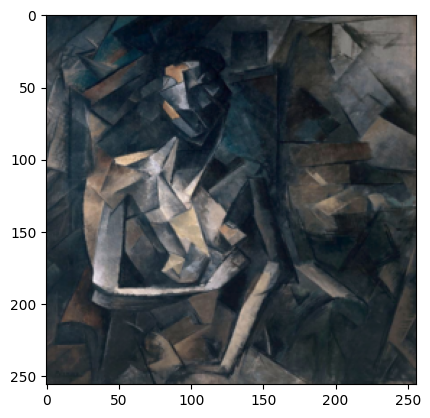

In [136]:
plt.imshow(unload_image(style_img))

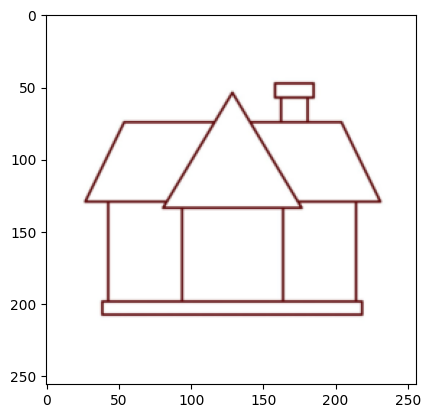

In [123]:
plt.imshow(unload_image(content_img))

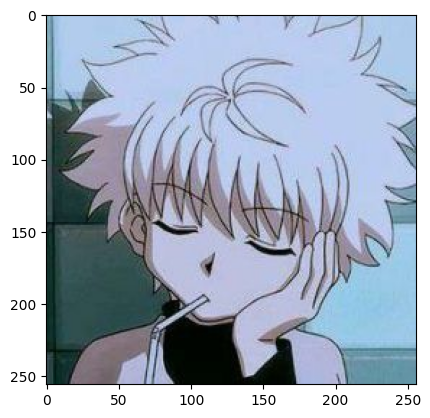

In [137]:
plt.imshow(unload_image(wf_img))

Iteration 100/2000 | Style Loss: 8.0960150 | Normalised Style Loss: 0.2891103|Content Loss: 2.7107263 | TV Loss: 0.1263641
Iteration 200/2000 | Style Loss: 7.5842557 | Normalised Style Loss: 0.2708353|Content Loss: 2.6510077 | TV Loss: 0.1423426
Iteration 300/2000 | Style Loss: 7.3620710 | Normalised Style Loss: 0.2629010|Content Loss: 2.6288104 | TV Loss: 0.1570721
Iteration 400/2000 | Style Loss: 7.2674775 | Normalised Style Loss: 0.2595230|Content Loss: 2.6038642 | TV Loss: 0.1694748
Iteration 500/2000 | Style Loss: 7.1993647 | Normalised Style Loss: 0.2570907|Content Loss: 2.5944695 | TV Loss: 0.1873542
Iteration 600/2000 | Style Loss: 7.1473436 | Normalised Style Loss: 0.2552330|Content Loss: 2.6079617 | TV Loss: 0.2063108
Iteration 700/2000 | Style Loss: 7.1144371 | Normalised Style Loss: 0.2540579|Content Loss: 2.5704396 | TV Loss: 0.2219083
Iteration 800/2000 | Style Loss: 7.0779176 | Normalised Style Loss: 0.2527538|Content Loss: 2.5653851 | TV Loss: 0.2343955
Iteration 900/20

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

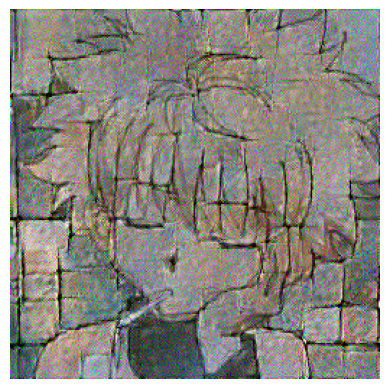

In [143]:

style_img = load_image(tiles_img_path, loader)
content_img = load_image(wf_img_path, loader)

sfe = StyleFeaturesExtractor(
    cnn=cnn,
    style_img=style_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

cfe = ContentFeaturesExtractor(
    cnn=cnn,
    content_image=content_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

output = run_style_transfer(style_features_extractor=sfe,
                            content_features_extractor=cfe,
                            num_steps=2000,
                            style_weight=3,
                            content_weight=0.2
                            )

generated_image = unload_image(output)
plt.imshow(generated_image)
plt.axis('off')


Iteration 100/2000 | Style Loss: 1.8231370 | Normalised Style Loss: 0.1404405|Content Loss: 1.3791411 | TV Loss: 0.0908863
Iteration 200/2000 | Style Loss: 1.7144449 | Normalised Style Loss: 0.1320677|Content Loss: 1.3312269 | TV Loss: 0.0916083
Iteration 300/2000 | Style Loss: 1.6801028 | Normalised Style Loss: 0.1294222|Content Loss: 1.3106217 | TV Loss: 0.0937492
Iteration 400/2000 | Style Loss: 1.6611054 | Normalised Style Loss: 0.1279588|Content Loss: 1.3009262 | TV Loss: 0.0960619
Iteration 500/2000 | Style Loss: 1.6488923 | Normalised Style Loss: 0.1270180|Content Loss: 1.2948866 | TV Loss: 0.0981892
Iteration 600/2000 | Style Loss: 1.6404767 | Normalised Style Loss: 0.1263697|Content Loss: 1.2899001 | TV Loss: 0.1002605
Iteration 700/2000 | Style Loss: 1.6342602 | Normalised Style Loss: 0.1258909|Content Loss: 1.2859257 | TV Loss: 0.1021120
Iteration 800/2000 | Style Loss: 1.6286987 | Normalised Style Loss: 0.1254625|Content Loss: 1.2831339 | TV Loss: 0.1039566
Iteration 900/20

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

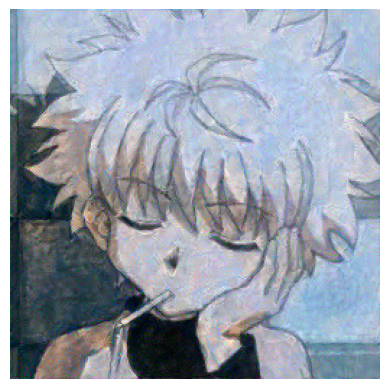

In [144]:

style_img = load_image(style_img_path, loader)
content_img = load_image(wf_img_path, loader)

sfe = StyleFeaturesExtractor(
    cnn=cnn,
    style_img=style_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

cfe = ContentFeaturesExtractor(
    cnn=cnn,
    content_image=content_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

output = run_style_transfer(style_features_extractor=sfe,
                            content_features_extractor=cfe,
                            num_steps=2000,
                            style_weight=3,
                            content_weight=0.2
                            )

generated_image = unload_image(output)
plt.imshow(generated_image)
plt.axis('off')


In [164]:

style_img = load_image(spiral_img_path, loader)
content_img = load_image(wf_img_path, loader)

sfe = StyleFeaturesExtractor(
    cnn=cnn,
    style_img=style_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

cfe = ContentFeaturesExtractor(
    cnn=cnn,
    content_image=content_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

output = run_style_transfer(style_features_extractor=sfe,
                            content_features_extractor=cfe,
                            num_steps=2000,
                            style_weight=1,
                            content_weight=0.2
                            )

generated_image = unload_image(output)
plt.imshow(generated_image)
plt.axis('off')


Iteration 100/2000 | Style Loss: 154.5669861 | Normalised Style Loss: 0.8151532|Content Loss: 0.2836188
Iteration 200/2000 | Style Loss: 140.7105103 | Normalised Style Loss: 0.7420771|Content Loss: 0.3351949
Iteration 300/2000 | Style Loss: 154.0756531 | Normalised Style Loss: 0.8125620|Content Loss: 0.4799193
Iteration 400/2000 | Style Loss: 146.5966797 | Normalised Style Loss: 0.7731194|Content Loss: 0.8309418
Iteration 500/2000 | Style Loss: 244.3516541 | Normalised Style Loss: 1.2886583|Content Loss: 11.3854923
Iteration 600/2000 | Style Loss: 244.3516541 | Normalised Style Loss: 1.2886583|Content Loss: 11.3854923
Iteration 700/2000 | Style Loss: 244.3516541 | Normalised Style Loss: 1.2886583|Content Loss: 11.3854923
Iteration 800/2000 | Style Loss: 244.3516541 | Normalised Style Loss: 1.2886583|Content Loss: 11.3854923
Iteration 900/2000 | Style Loss: 244.3516541 | Normalised Style Loss: 1.2886583|Content Loss: 11.3854923
Iteration 1000/2000 | Style Loss: 244.3516541 | Normalised 

KeyboardInterrupt: 

Iteration 100/2000 | Style Loss: 0.0018885 | Normalised Style Loss: 0.7153888|Content Loss: 0.3321719
Iteration 200/2000 | Style Loss: 0.0025079 | Normalised Style Loss: 0.9500592|Content Loss: 1.2579803
Iteration 300/2000 | Style Loss: 0.0018008 | Normalised Style Loss: 0.6821717|Content Loss: 0.5511558
Iteration 400/2000 | Style Loss: 0.0020203 | Normalised Style Loss: 0.7653255|Content Loss: 1.9404513
Iteration 500/2000 | Style Loss: 0.0047032 | Normalised Style Loss: 1.7816900|Content Loss: 11.1843977
Iteration 600/2000 | Style Loss: 0.0054281 | Normalised Style Loss: 2.0562770|Content Loss: 8.7876015
Iteration 700/2000 | Style Loss: 0.0023640 | Normalised Style Loss: 0.8955214|Content Loss: 1.1248394
Iteration 800/2000 | Style Loss: 0.0039487 | Normalised Style Loss: 1.4958669|Content Loss: 7.7388535
Iteration 900/2000 | Style Loss: 0.0055066 | Normalised Style Loss: 2.0860167|Content Loss: 6.6346974
Iteration 1000/2000 | Style Loss: 0.0054869 | Normalised Style Loss: 2.0785403|Co

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

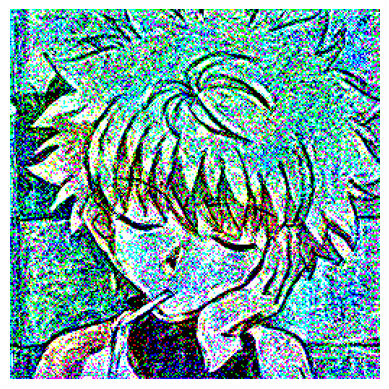

In [166]:

style_img = load_image(spiral_img_path, loader)
content_img = load_image(wf_img_path, loader)

sfe = StyleFeaturesExtractor(
    cnn=cnn,
    style_img=style_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

cfe = ContentFeaturesExtractor(
    cnn=cnn,
    content_image=content_img,
    normalization_mean=cnn_normalization_mean,
    normalization_std=cnn_normalization_std,
    num_layers=10
)

output = run_style_transfer(style_features_extractor=sfe,
                            content_features_extractor=cfe,
                            num_steps=2000,
                            style_weight=1,
                            content_weight=0.2
                            )

generated_image = unload_image(output)
plt.imshow(generated_image)
plt.axis('off')
